# Lab 2 — Robot System and Simulation

## Block 1 — Our Warehouse AMR

In Lab 1, we created a basic software representation of our
differential-drive warehouse AMR.

In this laboratory, we will extend that robot into a simple simulated
robotic system.

We will progressively add:

- a warehouse environment,
- robot–environment interaction,
- basic motion,
- and a simple simulation loop.

The robot itself remains the same robot introduced in Lab 1.

### Recall: Robot Pose

Our robot is represented by the pose:

    [x, y, θ]

where:

- x → position along the x-axis
- y → position along the y-axis
- θ → robot orientation

In this laboratory, we will use this state to place and move the robot
inside a simulated warehouse.

In [1]:
import numpy as np

class DifferentialDriveRobot:
    def __init__(self, x=0.0, y=0.0, theta=0.0):
        self.x = x
        self.y = y
        self.theta = theta

    def pose(self):
        return np.array([self.x, self.y, self.theta])

In [2]:
import matplotlib.pyplot as plt

def plot_robot(robot, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    x = robot.x
    y = robot.y
    theta = robot.theta

    length = 1.0
    width = 0.6

    corners = np.array([
        [-length / 2, -width / 2],
        [ length / 2, -width / 2],
        [ length / 2,  width / 2],
        [-length / 2,  width / 2],
        [-length / 2, -width / 2]
    ])

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated_corners = corners @ R.T
    rotated_corners += np.array([x, y])

    ax.plot(
        rotated_corners[:, 0],
        rotated_corners[:, 1],
        linewidth=2
    )

    heading_length = 0.8

    ax.arrow(
        x,
        y,
        heading_length * np.cos(theta),
        heading_length * np.sin(theta),
        head_width=0.15,
        length_includes_head=True
    )

    ax.plot(x, y, "o")

    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(True)

    return ax

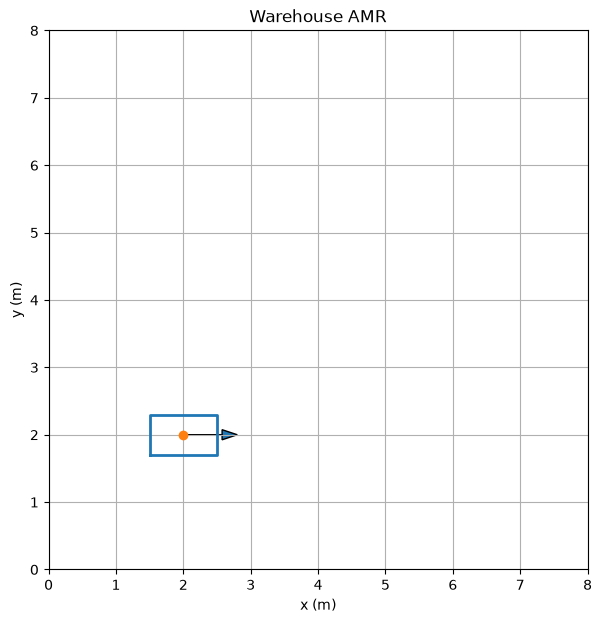

In [3]:
robot = DifferentialDriveRobot(
    x=2.0,
    y=2.0,
    theta=0.0
)

fig, ax = plt.subplots(figsize=(7, 7))
plot_robot(robot, ax)

ax.set_xlim(0, 8)
ax.set_ylim(0, 8)
ax.set_title("Warehouse AMR")

plt.show()

## Block 2 — Components of a Robotic System

A robot is more than its mechanical body.

A robotic system combines:

**Sensors → Perception / Processing → Decision → Actuation**

and operates within an **environment**.

Our warehouse AMR contains:

### Sensors
- Wheel encoders
- IMU
- 2D LiDAR
- RGB camera

### Processing
- Onboard computer

### Actuation
- Left and right drive wheels

### Environment
- Warehouse floor
- Storage racks
- Obstacles
- Navigation space

### Our AMR as a System

For our laboratory robot:

Sensors
↓
Robot computer
↓
Motion / decision
↓
Drive wheels
↓
Robot motion
↓
Warehouse environment
↓
Sensors observe the environment again

### What are we simulating?

In this laboratory we will initially simulate only the parts needed to
understand the basic robotic system:

- Robot state
- Robot motion
- Warehouse environment
- Robot–environment interaction
- Visualization

The physical sensors will be introduced progressively in later
laboratories.

For now, we focus on building the simulation foundation.

### Think Like a Robotics Engineer

Consider our warehouse AMR moving through a warehouse.

Ask:

**What does the robot need to know?**

**What does the robot need to sense?**

**What can the robot control?**

**What can the environment change?**

Keep these questions in mind as we build the simulation.

## Block 3 — Build the Warehouse Environment

A robot does not operate in isolation.

Our warehouse AMR operates inside a structured environment containing:

- a floor area,
- storage racks,
- obstacles,
- and free space for navigation.

We will represent the warehouse as a simple 2D map.

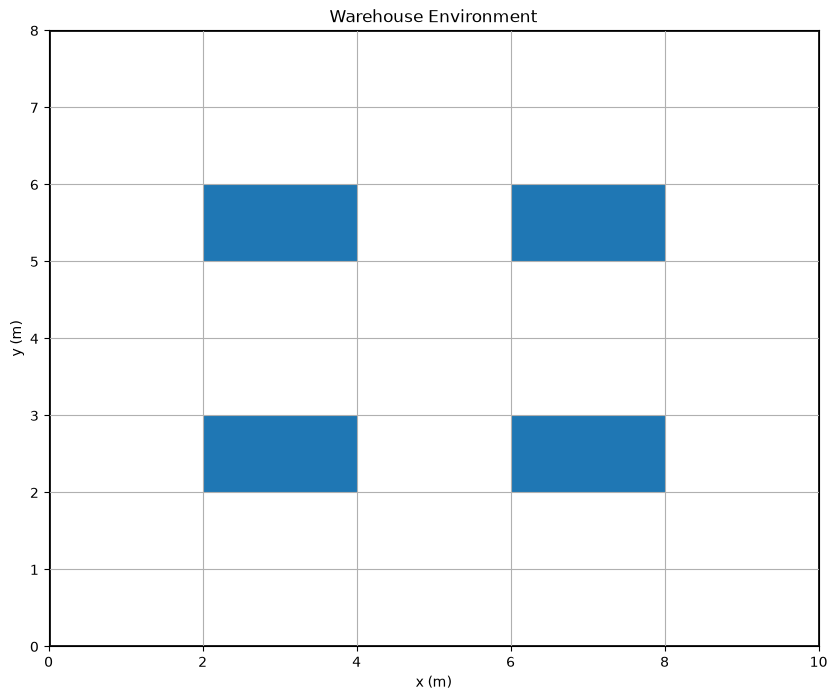

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Warehouse dimensions
warehouse_width = 10
warehouse_height = 8

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Warehouse boundary
ax.add_patch(
    Rectangle(
        (0, 0),
        warehouse_width,
        warehouse_height,
        fill=False,
        linewidth=2
    )
)

# Storage racks / obstacles
obstacles = [
    (2, 5, 2, 1),
    (6, 5, 2, 1),
    (2, 2, 2, 1),
    (6, 2, 2, 1)
]

for x, y, width, height in obstacles:
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            fill=True
        )
    )

ax.set_xlim(0, warehouse_width)
ax.set_ylim(0, warehouse_height)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Warehouse Environment")
ax.grid(True)

plt.show()

### 3.1 Representing Obstacles as Data

Instead of treating the obstacles only as drawings, we represent each
one using numerical values:

    (x, y, width, height)

This allows the same environment description to be used later by
robot motion, collision checking, and planning algorithms.

In [5]:
print("Warehouse dimensions:")
print("Width :", warehouse_width, "m")
print("Height:", warehouse_height, "m")

print("\nObstacles:")
for obstacle in obstacles:
    print(obstacle)

Warehouse dimensions:
Width : 10 m
Height: 8 m

Obstacles:
(2, 5, 2, 1)
(6, 5, 2, 1)
(2, 2, 2, 1)
(6, 2, 2, 1)


### Engineering Insight

The visualization and the environment model are different things.

The plot shows us **what the warehouse looks like**.

The numerical representation tells the computer **what exists in the
warehouse**.

This distinction becomes important when we later implement collision
checking, sensing, localization, and planning.

In [ ]:
### Exercise 3.1 — Modify the Warehouse

Add one more rectangular obstacle to the `obstacles` list.

For example:

    (4, 3.5, 1, 1)

Run the visualization again.

Observe how the environment changes without changing the robot.

## Block 4 — Place the AMR in the Warehouse

We now combine the robot and the warehouse environment.

The robot has its own state:

    [x, y, θ]

The warehouse has its own environment description.

Our goal is to visualize both together.

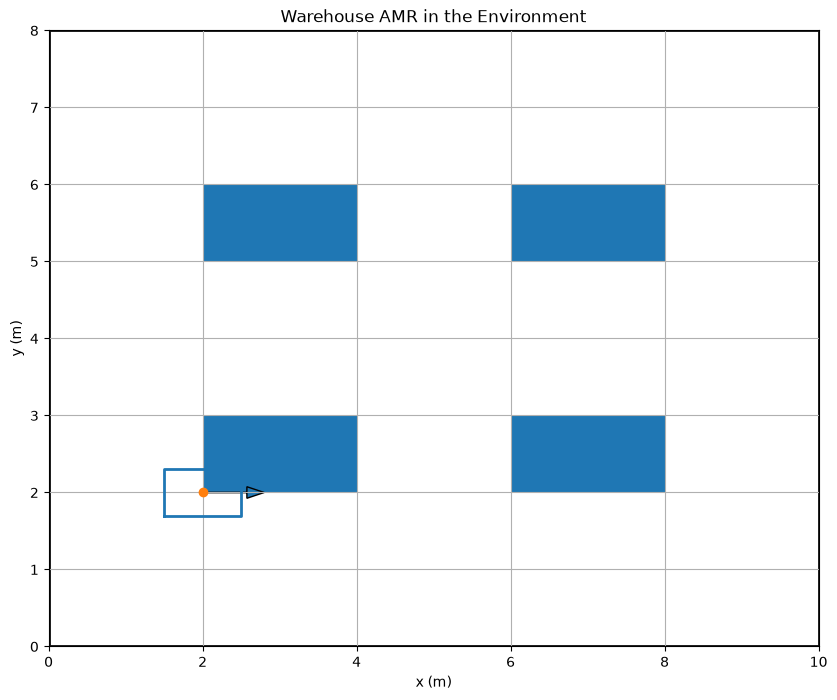

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# Warehouse boundary
ax.add_patch(
    Rectangle(
        (0, 0),
        warehouse_width,
        warehouse_height,
        fill=False,
        linewidth=2
    )
)

# Draw obstacles
for x, y, width, height in obstacles:
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            fill=True
        )
    )

# Draw the robot
plot_robot(robot, ax)

ax.set_xlim(0, warehouse_width)
ax.set_ylim(0, warehouse_height)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Warehouse AMR in the Environment")
ax.grid(True)

plt.show()

### Observe

The robot and environment are represented separately in the program,
but they are now visualized together.

This separation is important:

- The **robot** contains its state.
- The **environment** contains the surrounding world.
- The **simulation** will eventually describe how they interact.

### Exercise 4.1 — Change the Starting Position

Change the robot's initial position so that it starts in a different
free-space location in the warehouse.

For example:

    x = 1.0 m
    y = 1.0 m

Keep the orientation unchanged.

Visualize the result again.

**Question:** Is the new starting position inside free space or inside
an obstacle?

## Block 5 — Basic Robot Motion

So far, our robot has only had a fixed pose.

A simulated robot should be able to change its state when a motion
command is applied.

For this first simulation, we use a simple motion model:

- `v` → forward velocity
- `dt` → simulation time step

For a robot moving straight ahead:

    x_new = x + v cos(θ) dt
    y_new = y + v sin(θ) dt

For now, the orientation θ remains unchanged.

This is a simple deterministic simulation. Motion uncertainty will be
introduced in a later laboratory.

In [7]:
def move_robot(robot, v, dt):
    robot.x += v * np.cos(robot.theta) * dt
    robot.y += v * np.sin(robot.theta) * dt

### Understanding the Motion Equation

The code:

    x += v * cos(θ) * dt
    y += v * sin(θ) * dt

may look unfamiliar, but the idea is simple.

The robot moves a distance:

    distance = velocity × time

However, the robot may not be pointing along the x-axis.

The terms:

    cos(θ) → portion of motion along x
    sin(θ) → portion of motion along y

Therefore:

    change in x = v cos(θ) dt
    change in y = v sin(θ) dt

### Example

If:

    θ = 0°

the robot faces along +x:

    cos(0°) = 1
    sin(0°) = 0

So the robot moves only along x.

If:

    θ = 90°

the robot faces along +y:

    cos(90°) = 0
    sin(90°) = 1

So the robot moves only along y.

**The equation simply converts forward motion of the robot into
movement along the x and y directions of the world.**

In [8]:
# Reset the robot
robot = DifferentialDriveRobot(
    x=1.0,
    y=1.0,
    theta=0.0
)

print("Initial pose:", robot.pose())

# Move forward for 1 second at 1 m/s
move_robot(robot, v=1.0, dt=1.0)

print("Pose after motion:", robot.pose())

Initial pose: [1. 1. 0.]
Pose after motion: [2. 1. 0.]


### Observe

The robot moved forward along its current heading.

The robot's orientation did not change.

This gives us the basic simulation relationship:

**Motion command → State update → New robot pose**

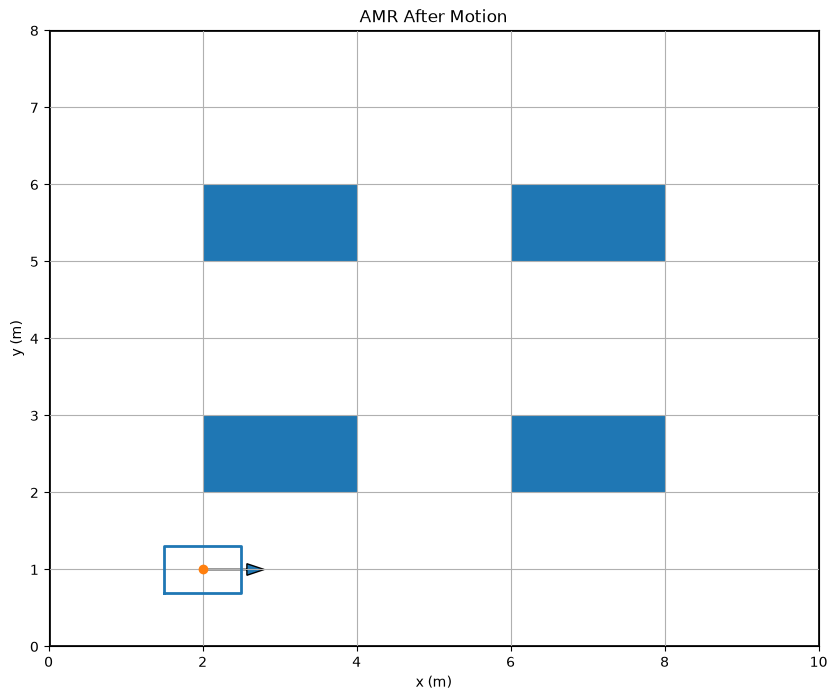

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Warehouse
ax.add_patch(
    Rectangle(
        (0, 0),
        warehouse_width,
        warehouse_height,
        fill=False,
        linewidth=2
    )
)

for x, y, width, height in obstacles:
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            fill=True
        )
    )

plot_robot(robot, ax)

ax.set_xlim(0, warehouse_width)
ax.set_ylim(0, warehouse_height)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("AMR After Motion")
ax.grid(True)

plt.show()

### Exercise 5.1 — Change the Motion

Starting from:

    x = 2.0 m
    y = 2.0 m
    θ = π/2 rad

move the robot forward at:

    v = 0.5 m/s

for:

    dt = 2 s

Predict the new position **before running the code**.

Then run the simulation and compare your prediction with the result.

## Block 6 — Simulation Loop

A robot simulation repeatedly updates the robot state over small time
steps.

At each time step:

1. Apply a motion command.
2. Update the robot state.
3. Record the state.
4. Continue to the next time step.

This creates a simple simulation loop.

In [10]:
# Initial robot state
robot = DifferentialDriveRobot(
    x=1.0,
    y=1.0,
    theta=0.0
)

# Simulation parameters
v = 0.5       # m/s
dt = 0.1      # s
simulation_time = 5.0

# Store robot trajectory
trajectory = [robot.pose().copy()]

# Simulation loop
steps = int(simulation_time / dt)

for _ in range(steps):
    move_robot(robot, v, dt)
    trajectory.append(robot.pose().copy())

trajectory = np.array(trajectory)

print("Initial pose:", trajectory[0])
print("Final pose:", trajectory[-1])

Initial pose: [1. 1. 0.]
Final pose: [3.5 1.  0. ]


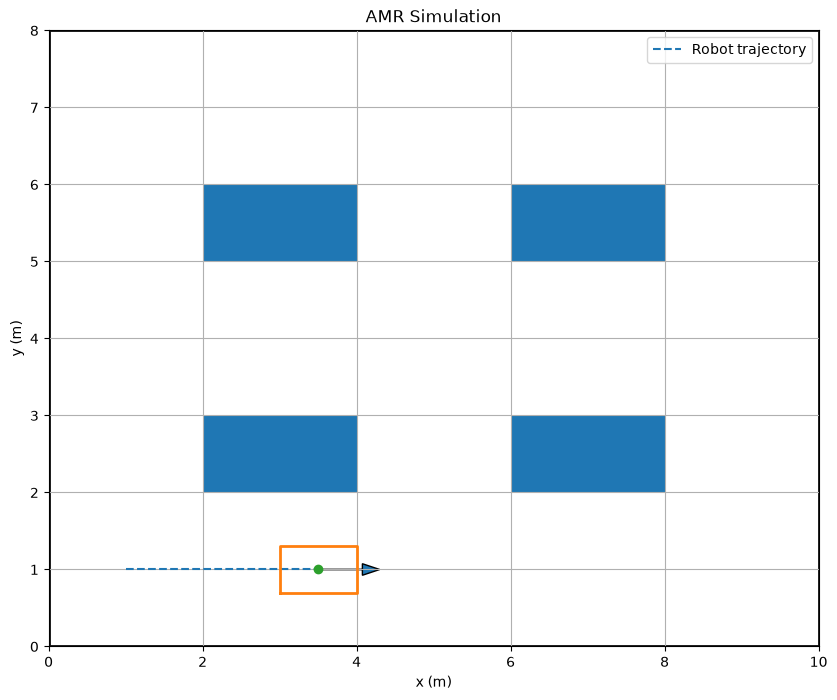

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

# Warehouse
ax.add_patch(
    Rectangle(
        (0, 0),
        warehouse_width,
        warehouse_height,
        fill=False,
        linewidth=2
    )
)

# Obstacles
for x, y, width, height in obstacles:
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            fill=True
        )
    )

# Robot trajectory
ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    linestyle="--",
    label="Robot trajectory"
)

# Final robot position
plot_robot(robot, ax)

ax.set_xlim(0, warehouse_width)
ax.set_ylim(0, warehouse_height)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("AMR Simulation")
ax.legend()
ax.grid(True)

plt.show()

### Observe the Simulation

The dashed line represents the path followed by the robot.

The simulation has now moved beyond a single robot pose:

**Initial state**

↓

**Repeated motion updates**

↓

**Sequence of robot states**

↓

**Robot trajectory**

### Visualizing the Robot Motion

The previous plot showed the complete trajectory after the simulation
finished.

We can also visualize the simulation as it happens.

The robot will move through the warehouse one time step at a time.

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Initial robot state
robot = DifferentialDriveRobot(
    x=1.0,
    y=1.0,
    theta=0.0
)

v = 0.5
dt = 0.1
simulation_time = 5.0
steps = int(simulation_time / dt)

# Generate trajectory
trajectory = [robot.pose().copy()]

for _ in range(steps):
    move_robot(robot, v, dt)
    trajectory.append(robot.pose().copy())

trajectory = np.array(trajectory)

print("Start:", trajectory[0])
print("End  :", trajectory[-1])

Start: [1. 1. 0.]
End  : [3.5 1.  0. ]


In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

# Warehouse
ax.add_patch(
    Rectangle(
        (0, 0),
        warehouse_width,
        warehouse_height,
        fill=False,
        linewidth=2
    )
)

for x, y, width, height in obstacles:
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            fill=True
        )
    )

# Complete trajectory
ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    linestyle="--",
    alpha=0.4
)

ax.set_xlim(0, warehouse_width)
ax.set_ylim(0, warehouse_height)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("AMR Motion Simulation")
ax.grid(True)

# Robot body
robot_patch, = ax.plot([], [], linewidth=2)

# Current heading arrow
heading_arrow = None


def update(frame):

    global heading_arrow

    x, y, theta = trajectory[frame]

    # Robot body
    length = 1.0
    width = 0.6

    corners = np.array([
        [-length / 2, -width / 2],
        [ length / 2, -width / 2],
        [ length / 2,  width / 2],
        [-length / 2,  width / 2],
        [-length / 2, -width / 2]
    ])

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    corners = corners @ R.T
    corners += np.array([x, y])

    robot_patch.set_data(
        corners[:, 0],
        corners[:, 1]
    )

    # Remove previous arrow
    if heading_arrow is not None:
        heading_arrow.remove()

    # Draw current heading
    heading_arrow = ax.arrow(
        x,
        y,
        0.8 * np.cos(theta),
        0.8 * np.sin(theta),
        head_width=0.15,
        length_includes_head=True
    )

    return robot_patch,


animation = FuncAnimation(
    fig,
    update,
    frames=range(len(trajectory)),
    interval=100,
    repeat=False,
    blit=False
)

plt.close(fig)

HTML(animation.to_jshtml())

### Exercise 6.1 — Change the Simulation

Change the simulation parameters:

- velocity `v = 0.8 m/s`
- simulation time `simulation_time = 6 s`

Run the simulation again.

Observe how the robot trajectory changes.

### Think

What happens to the distance travelled when:

1. The velocity increases?
2. The simulation time increases?

## Block 7 — Lab 2 Checkpoint

You have now built a simple simulated warehouse AMR.

Your task is to modify the simulation and observe the result.

### Task

Create a simulation in which the robot:

- starts at `(1.0, 1.0)`
- faces along the +x direction
- moves at `0.6 m/s`
- runs for `4 seconds`

Then:

1. Visualize the warehouse.
2. Show the robot trajectory.
3. Display the animated robot.

### Before running

Predict:

- Where will the robot finish?
- How far will it travel?
- Will changing the velocity change the shape of the trajectory?

In [ ]:
# your code goes here

### Check Your Prediction

For straight-line motion:

    distance = velocity × time

Therefore:

    distance = 0.6 × 4

The robot should travel **2.4 m** along its current heading.

Starting from `(1.0, 1.0)`, the expected final position is approximately:

    (3.4, 1.0)

## Reflection

Answer briefly:

1. What are the main components of the simulated robotic system?

2. What information does the robot pose `[x, y, θ]` represent?

3. What happens to the robot state during each simulation time step?

4. Why do we keep the robot model and warehouse environment as separate
   objects/data structures?

5. What is the difference between a robot trajectory and a robot pose?

## Lab 2 Complete

You have now moved from representing a robot to building a simple
robotic system.

**Robot**
+
**Environment**
+
**Motion**
+
**Simulation loop**
=
**Basic Robot Simulation**

This simulation will become the foundation for the more intelligent
robotic system developed in the following laboratories.